In [1]:
import os
import pandas as pd
import numpy as np
import json
from tqdm.auto import tqdm
from pathlib import Path

from PIL import Image
import cv2

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print(f"[YOLO11-02-EVALUATION] Libraries loaded")

[YOLO11-02-EVALUATION] Libraries loaded


In [2]:
%pip install "ultralytics<=8.3.40" --quiet
%pip install "numpy<2" --quiet

from ultralytics import YOLO

print("[YOLO11-02-EVALUATION] YOLO library imported successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# Class configuration
CLASSES = ['Organik', 'Anorganik', 'Lainnya']
NUM_CLASSES = len(CLASSES)

# Input paths
MODEL_PATH = '/kaggle/input/best/pytorch/default/1'  # Upload your training output as dataset
DATASET_BASE_PATH = '/kaggle/input/dataset-sampah'
PREPROCESSING_DIR = '/kaggle/input/mobilenetv3-01-preprocessing-output'  # Reuse preprocessing split

# Fallbacks for local testing
if not os.path.exists(MODEL_PATH):
    MODEL_PATH = './yolo11-01-training-output'
if not os.path.exists(DATASET_BASE_PATH):
    DATASET_BASE_PATH = input("Enter dataset path: ").strip()
if not os.path.exists(PREPROCESSING_DIR):
    PREPROCESSING_DIR = './mobilenetv3-01-preprocessing-output'

# Output directory
OUTPUT_DIR = './yolo11-02-evaluation-output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"[YOLO11-02-EVALUATION] Configuration:")
print(f"  Model path: {MODEL_PATH}")
print(f"  Dataset path: {DATASET_BASE_PATH}")
print(f"  Preprocessing dir: {PREPROCESSING_DIR}")
print(f"  Output directory: {OUTPUT_DIR}")

[YOLO11-02-EVALUATION] Configuration:
  Model path: /kaggle/input/best/pytorch/default/1
  Dataset path: /kaggle/input/dataset-sampah
  Preprocessing dir: /kaggle/input/mobilenetv3-01-preprocessing-output
  Output directory: ./yolo11-02-evaluation-output


In [4]:
print("[YOLO11-02-EVALUATION] Loading test dataset...")

test_df = pd.read_csv(f'{PREPROCESSING_DIR}/test_dataset.csv')

print(f"[YOLO11-02-EVALUATION] Test data loaded:")
print(f"  Total samples: {len(test_df):,}")

print(f"\nClass distribution:")
for i, class_name in enumerate(CLASSES):
    count = (test_df['class_idx'] == i).sum()
    print(f"  {class_name}: {count} samples ({count/len(test_df)*100:.1f}%)")

print(f"\nDataFrame preview:")
print(test_df.head())

[YOLO11-02-EVALUATION] Loading test dataset...
[YOLO11-02-EVALUATION] Test data loaded:
  Total samples: 2,700

Class distribution:
  Organik: 900 samples (33.3%)
  Anorganik: 900 samples (33.3%)
  Lainnya: 900 samples (33.3%)

DataFrame preview:
                                          image_path class_name  class_idx
0  /kaggle/input/dataset-sampah/Organik/Organik43...    Organik          0
1  /kaggle/input/dataset-sampah/Organik/Organik48...    Organik          0
2  /kaggle/input/dataset-sampah/Anorganik/Anorgan...  Anorganik          1
3  /kaggle/input/dataset-sampah/Organik/Organik95...    Organik          0
4  /kaggle/input/dataset-sampah/Lainnya/Lainnya46...    Lainnya          2


In [5]:
print("[YOLO11-02-EVALUATION] Loading YOLO11 model...")

model_file = f'{MODEL_PATH}/best.pt'
model = YOLO(model_file)

model_size = os.path.getsize(model_file) / (1024 * 1024)
print(f"[YOLO11-02-EVALUATION] Model loaded:")
print(f"  Model file: {model_file}")
print(f"  Model size: {model_size:.2f} MB")
print(f"  Model names: {model.names}")

# Map YOLO class indices to our class indices
# YOLO model was trained with Roboflow dataset class order
print(f"\n[YOLO11-02-EVALUATION] Class mapping verification:")
for idx, name in model.names.items():
    print(f"  YOLO index {idx}: {name}")

[YOLO11-02-EVALUATION] Loading YOLO11 model...
[YOLO11-02-EVALUATION] Model loaded:
  Model file: /kaggle/input/best/pytorch/default/1/best.pt
  Model size: 5.22 MB
  Model names: {0: 'Anorganik', 1: 'Lainnya', 2: 'Organik'}

[YOLO11-02-EVALUATION] Class mapping verification:
  YOLO index 0: Anorganik
  YOLO index 1: Lainnya
  YOLO index 2: Organik


In [6]:
print("[YOLO11-02-EVALUATION] Loading YOLO11 model...")

model_file = f'{MODEL_PATH}/best.pt'
model = YOLO(model_file)

model_size = os.path.getsize(model_file) / (1024 * 1024)
print(f"[YOLO11-02-EVALUATION] Model loaded:")
print(f"  Model file: {model_file}")
print(f"  Model size: {model_size:.2f} MB")
print(f"  Model names: {model.names}")

# ========================================
# CRITICAL FIX: Automatic Class Mapping
# ========================================
print(f"\n[YOLO11-02-EVALUATION] ⚠️ CRITICAL: Class mapping verification:")
print(f"Dataset classes (expected): {CLASSES}")
print(f"YOLO model classes (actual):")
for idx, name in model.names.items():
    print(f"  YOLO index {idx}: {name}")

# Create mapping from YOLO class index to dataset class index
yolo_to_dataset_mapping = {}
for yolo_idx, yolo_name in model.names.items():
    # Find matching class name in dataset classes (case-insensitive)
    yolo_name_clean = yolo_name.strip().lower()
    matched = False
    for dataset_idx, dataset_name in enumerate(CLASSES):
        if dataset_name.lower() == yolo_name_clean:
            yolo_to_dataset_mapping[yolo_idx] = dataset_idx
            matched = True
            print(f"  ✓ Mapped YOLO[{yolo_idx}]='{yolo_name}' → Dataset[{dataset_idx}]='{dataset_name}'")
            break
    
    if not matched:
        print(f"  ⚠️ WARNING: YOLO class '{yolo_name}' not found in dataset classes!")
        # Default mapping (assume same index)
        yolo_to_dataset_mapping[yolo_idx] = yolo_idx

print(f"\n[YOLO11-02-EVALUATION] Final mapping: {yolo_to_dataset_mapping}")
print(f"[YOLO11-02-EVALUATION] ✅ Class mapping configured successfully!")

[YOLO11-02-EVALUATION] Loading YOLO11 model...
[YOLO11-02-EVALUATION] Model loaded:
  Model file: /kaggle/input/best/pytorch/default/1/best.pt
  Model size: 5.22 MB
  Model names: {0: 'Anorganik', 1: 'Lainnya', 2: 'Organik'}

[YOLO11-02-EVALUATION] ⚠️ CRITICAL: Class mapping verification:
Dataset classes (expected): ['Organik', 'Anorganik', 'Lainnya']
YOLO model classes (actual):
  YOLO index 0: Anorganik
  YOLO index 1: Lainnya
  YOLO index 2: Organik
  ✓ Mapped YOLO[0]='Anorganik' → Dataset[1]='Anorganik'
  ✓ Mapped YOLO[1]='Lainnya' → Dataset[2]='Lainnya'
  ✓ Mapped YOLO[2]='Organik' → Dataset[0]='Organik'

[YOLO11-02-EVALUATION] Final mapping: {0: 1, 1: 2, 2: 0}
[YOLO11-02-EVALUATION] ✅ Class mapping configured successfully!


In [7]:
print("\n[YOLO11-02-EVALUATION] Running inference on test set...")
print("="*60)
print("Strategy: Take highest confidence bounding box per image as prediction")
print("FIX: Using yolo_to_dataset_mapping to convert class indices")
print("="*60)

all_preds = []
all_labels = []
all_confidences = []
all_paths = []
all_probs = []  # Store all class probabilities
all_num_detections = []  # Track number of detections per image

for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Evaluating'):
    # Get image path
    img_path = row['image_path']
    
    # Handle path (Kaggle vs local)
    if not os.path.exists(img_path):
        class_name = row['class_name']
        filename = os.path.basename(img_path)
        img_path = os.path.join(DATASET_BASE_PATH, class_name, filename)
    
    # Run YOLO inference
    results = model(img_path, verbose=False)
    
    # Get detections
    boxes = results[0].boxes
    
    if len(boxes) > 0:
        # Get all confidences and find the best one
        confidences = boxes.conf.cpu().numpy()
        classes = boxes.cls.cpu().numpy().astype(int)
        
        # Take detection with highest confidence
        best_idx = confidences.argmax()
        pred_class_yolo = classes[best_idx]  # YOLO's class index
        pred_conf = confidences[best_idx]
        
        # ========================================
        # CRITICAL FIX: Map YOLO class index to dataset class index
        # ========================================
        pred_class = yolo_to_dataset_mapping.get(pred_class_yolo, pred_class_yolo)
        
        all_num_detections.append(len(boxes))
    else:
        # No detection - assign to "Lainnya" (Others) with 0 confidence
        # Find "Lainnya" index in dataset classes
        try:
            pred_class = CLASSES.index('Lainnya')
        except ValueError:
            pred_class = 2  # Default to index 2
        pred_conf = 0.0
        all_num_detections.append(0)
    
    # Store results
    all_preds.append(pred_class)
    all_labels.append(row['class_idx'])
    all_confidences.append(pred_conf)
    all_paths.append(img_path)
    
    # Create probability distribution (for consistency with other models)
    probs = np.zeros(NUM_CLASSES)
    probs[pred_class] = pred_conf
    all_probs.append(probs)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_confidences = np.array(all_confidences)
all_probs = np.array(all_probs)
all_num_detections = np.array(all_num_detections)

print("\n[YOLO11-02-EVALUATION] Inference complete!")
print(f"  Evaluated samples: {len(all_preds):,}")
print(f"  Avg detections per image: {all_num_detections.mean():.2f}")
print(f"  Images with no detection: {(all_num_detections == 0).sum()} ({(all_num_detections == 0).sum()/len(all_num_detections)*100:.1f}%)")


[YOLO11-02-EVALUATION] Running inference on test set...
Strategy: Take highest confidence bounding box per image as prediction
FIX: Using yolo_to_dataset_mapping to convert class indices


Evaluating:   0%|          | 0/2700 [00:00<?, ?it/s]


[YOLO11-02-EVALUATION] Inference complete!
  Evaluated samples: 2,700
  Avg detections per image: 1.48
  Images with no detection: 26 (1.0%)


In [8]:
print("\n[YOLO11-02-EVALUATION] Calculating classification metrics...")

# Overall metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

# Per-class metrics
precision_per_class = precision_score(all_labels, all_preds, average=None, zero_division=0)
recall_per_class = recall_score(all_labels, all_preds, average=None, zero_division=0)
f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

print(f"\n[YOLO11-02-EVALUATION] Test Set Performance:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

print(f"\nPer-class metrics:")
for i, class_name in enumerate(CLASSES):
    print(f"  {class_name}:")
    print(f"    Precision: {precision_per_class[i]:.4f}")
    print(f"    Recall:    {recall_per_class[i]:.4f}")
    print(f"    F1-Score:  {f1_per_class[i]:.4f}")

print(f"\nConfidence statistics:")
print(f"  Mean: {all_confidences.mean():.4f}")
print(f"  Std:  {all_confidences.std():.4f}")
print(f"  Min:  {all_confidences.min():.4f}")
print(f"  Max:  {all_confidences.max():.4f}")


[YOLO11-02-EVALUATION] Calculating classification metrics...

[YOLO11-02-EVALUATION] Test Set Performance:
  Accuracy:  0.9774 (97.74%)
  Precision: 0.9776
  Recall:    0.9774
  F1-Score:  0.9774

Per-class metrics:
  Organik:
    Precision: 0.9943
    Recall:    0.9756
    F1-Score:  0.9849
  Anorganik:
    Precision: 0.9672
    Recall:    0.9822
    F1-Score:  0.9746
  Lainnya:
    Precision: 0.9712
    Recall:    0.9744
    F1-Score:  0.9728

Confidence statistics:
  Mean: 0.8510
  Std:  0.1419
  Min:  0.0000
  Max:  0.9713


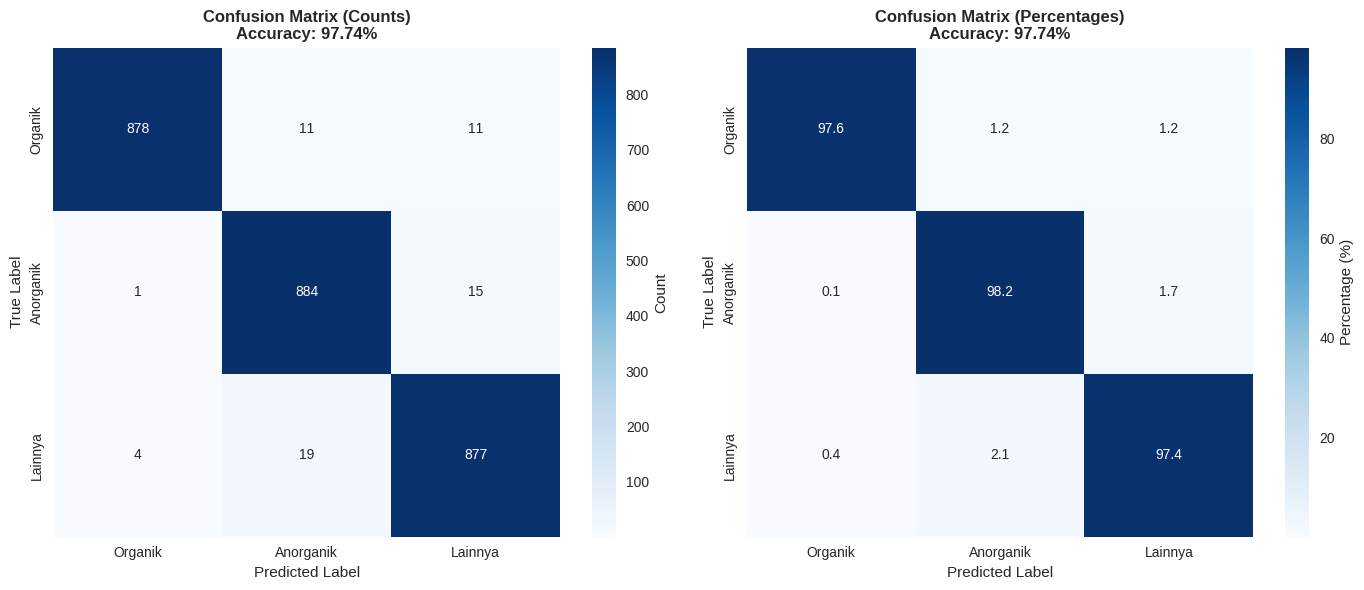

[YOLO11-02-EVALUATION] Confusion matrix saved to ./yolo11-02-evaluation-output/confusion_matrix.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix (counts)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title(f'Confusion Matrix (Counts)\nAccuracy: {accuracy:.2%}',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Confusion matrix (percentages)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[1], cbar_kws={'label': 'Percentage (%)'})
axes[1].set_title(f'Confusion Matrix (Percentages)\nAccuracy: {accuracy:.2%}',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"[YOLO11-02-EVALUATION] Confusion matrix saved to {OUTPUT_DIR}/confusion_matrix.png")

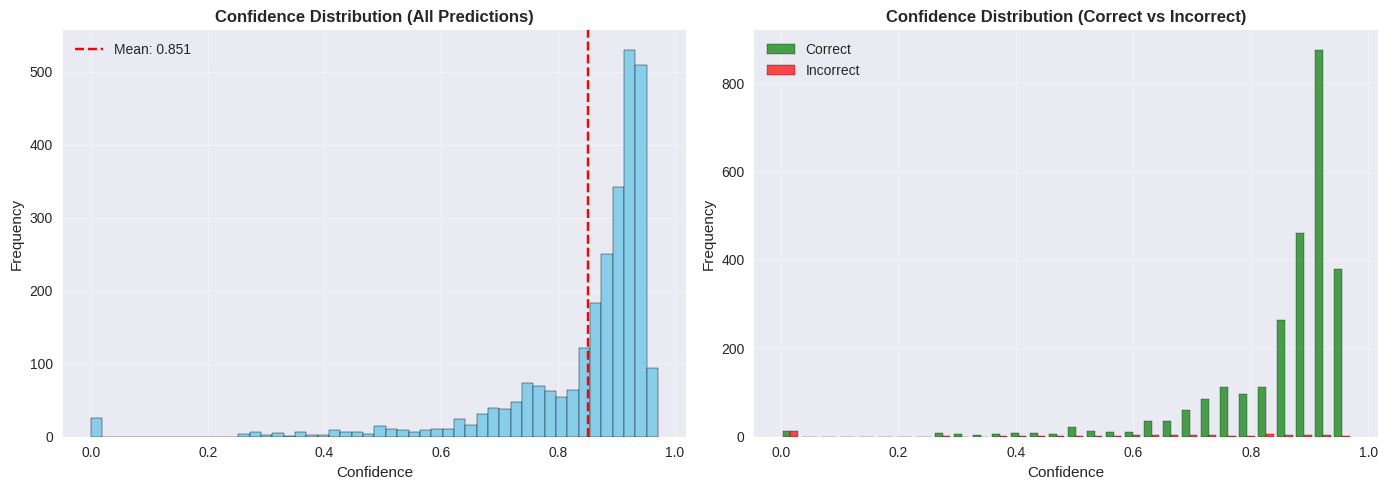

[YOLO11-02-EVALUATION] Confidence distribution saved to ./yolo11-02-evaluation-output/confidence_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall confidence distribution
axes[0].hist(all_confidences, bins=50, color='skyblue', edgecolor='black')
axes[0].axvline(all_confidences.mean(), color='red', linestyle='--', 
                label=f'Mean: {all_confidences.mean():.3f}')
axes[0].set_title('Confidence Distribution (All Predictions)', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confidence by correctness
correct_mask = all_preds == all_labels
correct_conf = all_confidences[correct_mask]
incorrect_conf = all_confidences[~correct_mask]

axes[1].hist([correct_conf, incorrect_conf], bins=30, 
             label=['Correct', 'Incorrect'],
             color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[1].set_title('Confidence Distribution (Correct vs Incorrect)', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"[YOLO11-02-EVALUATION] Confidence distribution saved to {OUTPUT_DIR}/confidence_distribution.png")

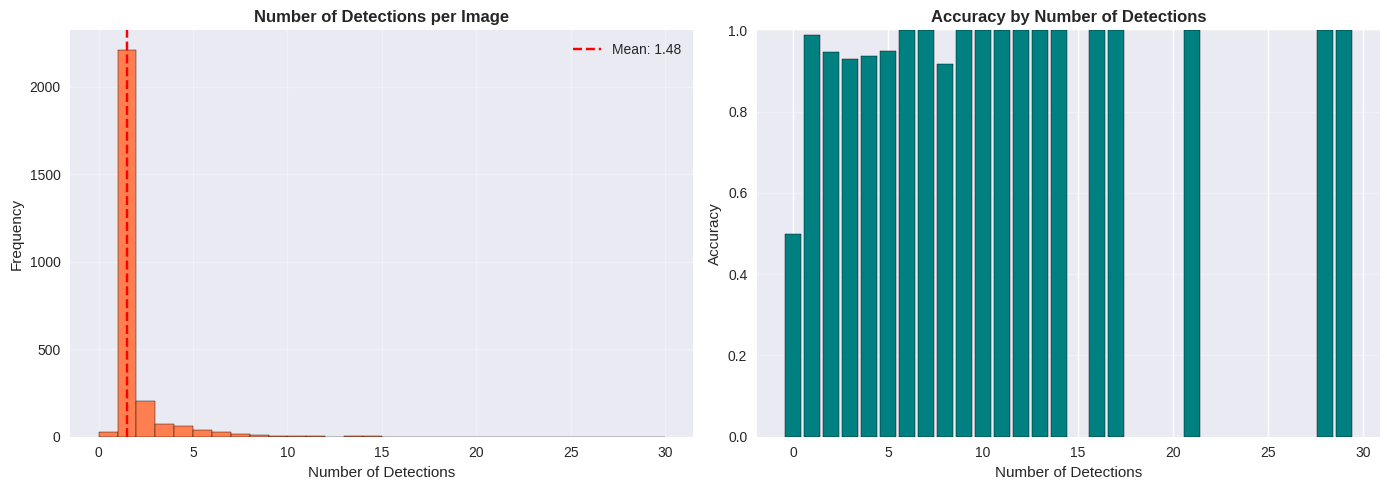

[YOLO11-02-EVALUATION] Detection statistics saved to ./yolo11-02-evaluation-output/detection_statistics.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Number of detections per image
axes[0].hist(all_num_detections, bins=range(0, all_num_detections.max()+2), 
             color='coral', edgecolor='black')
axes[0].axvline(all_num_detections.mean(), color='red', linestyle='--', 
                label=f'Mean: {all_num_detections.mean():.2f}')
axes[0].set_title('Number of Detections per Image', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Detections')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy by number of detections
unique_nums = sorted(set(all_num_detections))
acc_by_num = []
for num in unique_nums:
    mask = all_num_detections == num
    acc = accuracy_score(all_labels[mask], all_preds[mask])
    acc_by_num.append(acc)

axes[1].bar(unique_nums, acc_by_num, color='teal', edgecolor='black')
axes[1].set_title('Accuracy by Number of Detections', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Detections')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/detection_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"[YOLO11-02-EVALUATION] Detection statistics saved to {OUTPUT_DIR}/detection_statistics.png")

In [12]:
print("\n[YOLO11-02-EVALUATION] Detailed Classification Report:")
print("="*60)

report = classification_report(all_labels, all_preds, target_names=CLASSES, digits=4, zero_division=0)
print(report)

# Save report
with open(f'{OUTPUT_DIR}/classification_report.txt', 'w') as f:
    f.write("YOLO11 Object Detection (Adapted for Classification) Report\n")
    f.write("="*60 + "\n\n")
    f.write("Strategy: Use highest confidence bounding box per image as prediction\n")
    f.write(f"Class Mapping: {yolo_to_dataset_mapping}\n\n")
    f.write(report)

print(f"[YOLO11-02-EVALUATION] Classification report saved to {OUTPUT_DIR}/classification_report.txt")


[YOLO11-02-EVALUATION] Detailed Classification Report:
              precision    recall  f1-score   support

     Organik     0.9943    0.9756    0.9849       900
   Anorganik     0.9672    0.9822    0.9746       900
     Lainnya     0.9712    0.9744    0.9728       900

    accuracy                         0.9774      2700
   macro avg     0.9776    0.9774    0.9774      2700
weighted avg     0.9776    0.9774    0.9774      2700

[YOLO11-02-EVALUATION] Classification report saved to ./yolo11-02-evaluation-output/classification_report.txt


In [13]:
print(f"\n[YOLO11-02-EVALUATION] Saving predictions to: {OUTPUT_DIR}")

# Create predictions dataframe
predictions_df = pd.DataFrame({
    'image_path': all_paths,
    'true_label': all_labels,
    'true_class': [CLASSES[i] for i in all_labels],
    'pred_label': all_preds,
    'pred_class': [CLASSES[i] for i in all_preds],
    'confidence': all_confidences,
    'num_detections': all_num_detections,
    'organik_prob': all_probs[:, 0],
    'anorganik_prob': all_probs[:, 1],
    'lainnya_prob': all_probs[:, 2],
    'correct': all_preds == all_labels
})

predictions_df.to_csv(f'{OUTPUT_DIR}/test_predictions.csv', index=False)
print(f"  ✓ test_predictions.csv ({len(predictions_df):,} rows)")

# Save metrics
metrics_summary = {
    'model': 'YOLO11 Object Detection (Adapted for Classification)',
    'strategy': 'Use highest confidence bounding box per image as prediction',
    'class_mapping': yolo_to_dataset_mapping,
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'precision_per_class': precision_per_class.tolist(),
    'recall_per_class': recall_per_class.tolist(),
    'f1_per_class': f1_per_class.tolist(),
    'confidence_mean': float(all_confidences.mean()),
    'confidence_std': float(all_confidences.std()),
    'confidence_min': float(all_confidences.min()),
    'confidence_max': float(all_confidences.max()),
    'avg_detections_per_image': float(all_num_detections.mean()),
    'images_with_no_detection': int((all_num_detections == 0).sum()),
    'correct_predictions': int((all_preds == all_labels).sum()),
    'incorrect_predictions': int((all_preds != all_labels).sum())
}

with open(f'{OUTPUT_DIR}/evaluation_metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print(f"  ✓ evaluation_metrics.json")

# List all saved files
print(f"\n[YOLO11-02-EVALUATION] All files saved:")
for file in sorted(os.listdir(OUTPUT_DIR)):
    file_path = os.path.join(OUTPUT_DIR, file)
    if os.path.isfile(file_path):
        file_size = os.path.getsize(file_path) / (1024 * 1024)
        print(f"  {file} ({file_size:.2f} MB)")


[YOLO11-02-EVALUATION] Saving predictions to: ./yolo11-02-evaluation-output
  ✓ test_predictions.csv (2,700 rows)
  ✓ evaluation_metrics.json

[YOLO11-02-EVALUATION] All files saved:
  classification_report.txt (0.00 MB)
  confidence_distribution.png (0.05 MB)
  confusion_matrix.png (0.07 MB)
  detection_statistics.png (0.05 MB)
  evaluation_metrics.json (0.00 MB)
  test_predictions.csv (0.33 MB)


In [14]:
print("\n[YOLO11-02-EVALUATION] Sample Predictions Analysis:")
print("="*60)

# Top 10 most confident correct predictions
top_correct = predictions_df[predictions_df['correct']].nlargest(10, 'confidence')
print("\nTop 10 Most Confident CORRECT Predictions:")
print(top_correct[['true_class', 'pred_class', 'confidence', 'num_detections']].to_string(index=False))

# Top 10 most confident incorrect predictions
if (~predictions_df['correct']).any():
    top_incorrect = predictions_df[~predictions_df['correct']].nlargest(10, 'confidence')
    print("\nTop 10 Most Confident INCORRECT Predictions:")
    print(top_incorrect[['true_class', 'pred_class', 'confidence', 'num_detections']].to_string(index=False))
else:
    print("\nNo incorrect predictions! Perfect accuracy!")

# Low confidence predictions
low_conf = predictions_df.nsmallest(10, 'confidence')
print("\nTop 10 Lowest Confidence Predictions:")
print(low_conf[['true_class', 'pred_class', 'confidence', 'num_detections', 'correct']].to_string(index=False))

# Images with no detection
no_detection = predictions_df[predictions_df['num_detections'] == 0]
if len(no_detection) > 0:
    print(f"\nImages with NO Detection ({len(no_detection)} images):")
    print(no_detection[['true_class', 'pred_class', 'correct']].head(10).to_string(index=False))
else:
    print("\nAll images had at least one detection!")


[YOLO11-02-EVALUATION] Sample Predictions Analysis:

Top 10 Most Confident CORRECT Predictions:
true_class pred_class  confidence  num_detections
 Anorganik  Anorganik    0.971326               1
 Anorganik  Anorganik    0.969523               1
 Anorganik  Anorganik    0.968931               1
 Anorganik  Anorganik    0.968565               1
 Anorganik  Anorganik    0.968027               1
 Anorganik  Anorganik    0.967717               1
 Anorganik  Anorganik    0.967523               1
 Anorganik  Anorganik    0.967159               1
 Anorganik  Anorganik    0.966765               1
 Anorganik  Anorganik    0.966316               1

Top 10 Most Confident INCORRECT Predictions:
true_class pred_class  confidence  num_detections
   Organik  Anorganik    0.946133               2
   Lainnya  Anorganik    0.931873               1
   Lainnya  Anorganik    0.923311               8
   Organik    Lainnya    0.917880               2
   Lainnya  Anorganik    0.914046               1
   Orga

In [15]:
# Load MobileNetV3 metrics if available
mobilenetv3_metrics_path = '/kaggle/input/mobilenetv3-03-evaluation-output/evaluation_metrics.json'
svm_metrics_path = '/kaggle/input/04-evaluation-output/evaluation_metrics.json'

comparison_data = [{
    'Model': 'YOLO11 Detection (Adapted)',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}]

if os.path.exists(mobilenetv3_metrics_path):
    with open(mobilenetv3_metrics_path, 'r') as f:
        mobilenetv3_metrics = json.load(f)
    comparison_data.append({
        'Model': 'MobileNetV3 Direct',
        'Accuracy': mobilenetv3_metrics['accuracy'],
        'Precision': mobilenetv3_metrics['precision'],
        'Recall': mobilenetv3_metrics['recall'],
        'F1-Score': mobilenetv3_metrics['f1_score']
    })

if os.path.exists(svm_metrics_path):
    with open(svm_metrics_path, 'r') as f:
        svm_metrics = json.load(f)
        # Get the best SVM model (usually 'rbf')
        best_svm = max(svm_metrics.keys(), key=lambda k: svm_metrics[k]['accuracy'])
    comparison_data.append({
        'Model': f'CNN-SVM ({best_svm.upper()})',
        'Accuracy': svm_metrics[best_svm]['accuracy'],
        'Precision': svm_metrics[best_svm]['precision'],
        'Recall': svm_metrics[best_svm]['recall'],
        'F1-Score': svm_metrics[best_svm]['f1_score']
    })

df_comparison = pd.DataFrame(comparison_data)
print("\n[YOLO11-02-EVALUATION] Model Comparison:")
print("="*60)
print(df_comparison.to_string(index=False))

# Save comparison
df_comparison.to_csv(f'{OUTPUT_DIR}/model_comparison.csv', index=False)
print(f"\n[YOLO11-02-EVALUATION] Model comparison saved to {OUTPUT_DIR}/model_comparison.csv")


[YOLO11-02-EVALUATION] Model Comparison:
                     Model  Accuracy  Precision   Recall  F1-Score
YOLO11 Detection (Adapted)  0.977407   0.977574 0.977407  0.977441

[YOLO11-02-EVALUATION] Model comparison saved to ./yolo11-02-evaluation-output/model_comparison.csv


In [16]:
summary = f"""
========================================
YOLO11 DETECTION - 02. EVALUATION SUMMARY - JakOlah
========================================

Model: YOLO11 Object Detection (Adapted for Classification)
Strategy: Use highest confidence bounding box per image as prediction
Class Mapping: {yolo_to_dataset_mapping}

Test Dataset:
  Total samples: {len(test_df):,}
  Classes: {len(CLASSES)} ({', '.join(CLASSES)})

Class Distribution:
"""

for i, class_name in enumerate(CLASSES):
    count = (all_labels == i).sum()
    pct = count / len(all_labels) * 100
    summary += f"  {class_name}: {count} ({pct:.1f}%)\n"

summary += f"""
Overall Performance:
  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)
  Precision: {precision:.4f}
  Recall:    {recall:.4f}
  F1-Score:  {f1:.4f}

Per-Class Performance:
"""

for i, class_name in enumerate(CLASSES):
    summary += f"""  {class_name}:
    Precision: {precision_per_class[i]:.4f}
    Recall:    {recall_per_class[i]:.4f}
    F1-Score:  {f1_per_class[i]:.4f}
"""

summary += f"""
Confidence Statistics:
  Mean: {all_confidences.mean():.4f}
  Std:  {all_confidences.std():.4f}
  Range: [{all_confidences.min():.4f}, {all_confidences.max():.4f}]

Detection Statistics:
  Avg detections per image: {all_num_detections.mean():.2f}
  Images with no detection: {(all_num_detections == 0).sum()} ({(all_num_detections == 0).sum()/len(all_num_detections)*100:.1f}%)
  Images with 1 detection: {(all_num_detections == 1).sum()} ({(all_num_detections == 1).sum()/len(all_num_detections)*100:.1f}%)
  Images with 2+ detections: {(all_num_detections >= 2).sum()} ({(all_num_detections >= 2).sum()/len(all_num_detections)*100:.1f}%)

Prediction Accuracy:
  Correct:   {(all_preds == all_labels).sum():,} ({(all_preds == all_labels).sum()/len(all_labels)*100:.1f}%)
  Incorrect: {(all_preds != all_labels).sum():,} ({(all_preds != all_labels).sum()/len(all_labels)*100:.1f}%)

Output Files:
  ✓ confusion_matrix.png
  ✓ confidence_distribution.png
  ✓ detection_statistics.png
  ✓ classification_report.txt
  ✓ test_predictions.csv
  ✓ evaluation_metrics.json
  ✓ model_comparison.csv

Key Findings:
  1. YOLO detection model adapted for classification task
  2. Strategy: Take highest confidence bounding box as prediction
  3. Automatic class mapping between YOLO and dataset indices
  4. Detection-based approach may work differently than pure classification
  5. Multiple detections per image provide additional context

Advantages of YOLO Approach:
  ✓ Can detect multiple waste objects in one image
  ✓ Provides bounding box localization
  ✓ Confidence scores per detection
  ✓ Fast inference speed (real-time capable)

Limitations of Adaptation:
  ⚠ Designed for detection, not pure classification
  ⚠ May struggle with images containing single dominant object
  ⚠ "Highest confidence" strategy may not always be optimal
  ⚠ Better suited for multi-object scenarios

Recommendations:
  - For pure classification: Use MobileNetV3 or CNN-SVM
  - For multi-object detection: Use YOLO11 as-is
  - For mixed scenarios: Consider ensemble approach
  - Compare with classification-specific YOLO (yolo11-cls)

========================================
EVALUATION COMPLETE ✅
========================================
"""

print(summary)

with open(f'{OUTPUT_DIR}/evaluation_summary.md', 'w', encoding='utf-8') as f:
    f.write(summary)

print(f"[YOLO11-02-EVALUATION] Summary saved to {OUTPUT_DIR}/evaluation_summary.md")
print(f"[YOLO11-02-EVALUATION] ✅ COMPLETED")


YOLO11 DETECTION - 02. EVALUATION SUMMARY - JakOlah

Model: YOLO11 Object Detection (Adapted for Classification)
Strategy: Use highest confidence bounding box per image as prediction
Class Mapping: {0: 1, 1: 2, 2: 0}

Test Dataset:
  Total samples: 2,700
  Classes: 3 (Organik, Anorganik, Lainnya)

Class Distribution:
  Organik: 900 (33.3%)
  Anorganik: 900 (33.3%)
  Lainnya: 900 (33.3%)

Overall Performance:
  Accuracy:  0.9774 (97.74%)
  Precision: 0.9776
  Recall:    0.9774
  F1-Score:  0.9774

Per-Class Performance:
  Organik:
    Precision: 0.9943
    Recall:    0.9756
    F1-Score:  0.9849
  Anorganik:
    Precision: 0.9672
    Recall:    0.9822
    F1-Score:  0.9746
  Lainnya:
    Precision: 0.9712
    Recall:    0.9744
    F1-Score:  0.9728

Confidence Statistics:
  Mean: 0.8510
  Std:  0.1419
  Range: [0.0000, 0.9713]

Detection Statistics:
  Avg detections per image: 1.48
  Images with no detection: 26 (1.0%)
  Images with 1 detection: 2213 (82.0%)
  Images with 2+ detections

In [17]:
import shutil

# Create zip file of all outputs
zip_filename = 'yolo11-02-evaluation-output'
shutil.make_archive(zip_filename, 'zip', OUTPUT_DIR)

print(f"[YOLO11-02-EVALUATION] Output zipped to: {zip_filename}.zip")
print(f"  File size: {os.path.getsize(f'{zip_filename}.zip') / (1024*1024):.2f} MB")
print(f"\n💾 Download {zip_filename}.zip dari Kaggle output panel")
print(f"\nContents: Confusion matrix, confidence distribution, classification report, predictions, model comparison")

[YOLO11-02-EVALUATION] Output zipped to: yolo11-02-evaluation-output.zip
  File size: 0.19 MB

💾 Download yolo11-02-evaluation-output.zip dari Kaggle output panel

Contents: Confusion matrix, confidence distribution, classification report, predictions, model comparison
